# Задание Pro

Используя модуль **datasets** библиотеки **sklearn**, загрузите базу вин (`.load_wine()`).

Используя шаблон ноутбука, выполните загрузку, подготовку и предобработку данных. Обязательное условие: разделение данных на три выборки осуществляется по шаблону (изменять параметры подготовки данных запрещается)!

Проведите серию экспериментов и добейтесь максимальной точности классификации на тестовой выборке выше 94%.

---

С помощью метода `.summary()` зафиксируйте количество параметров созданной вами нейронной сети.


In [1]:
# Последовательная модель НС
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization, Input

# Утилиты для to_categorical()
from tensorflow.keras import utils

# Алгоритмы оптимизации для обучения модели
from tensorflow.keras.optimizers import Adam

# Библиотека для работы с массивами
import numpy as np
import tensorflow as tf

# Отрисовка графиков
import matplotlib.pyplot as plt

# Разделение данных на выборки
from sklearn.model_selection import train_test_split

# Для загрузки датасета
from sklearn.datasets import load_wine

from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping

# Отрисовка изображений в ноутбуке, а не в консоли или файле
%matplotlib inline

In [5]:
class Wine_classific:
    def __init__(self, epochs=64, batch_size=8, use_bn=False):
        self.epochs = epochs
        self.batch_size = batch_size
        self.use_bn = use_bn
        self.scaler = StandardScaler()

    def load_data(self):
        x_data = load_wine()['data'].astype('float32')
        y_data = load_wine()['target']

        # фиксация случайности
        np.random.seed(42)
        tf.keras.utils.set_random_seed(42)

        # нормальное разбиение: 60% обучение, 20% валидация, 20% тест
        x_train_val, x_test, y_train_val, y_test = train_test_split(
            x_data,
            y_data,
            test_size=0.2,
            random_state=42,
            stratify=y_data
        )

        x_train, x_val, y_train, y_val = train_test_split(
            x_train_val,
            y_train_val,
            test_size=0.25,   # 0.25 от 0.8 = 0.2 от всего набора
            random_state=42,
            stratify=y_train_val
        )

        # стандартизация только по обучающей выборке
        x_train = self.scaler.fit_transform(x_train)
        x_val = self.scaler.transform(x_val)
        x_test = self.scaler.transform(x_test)

        return x_train, y_train, x_val, y_val, x_test, y_test

    def create_model(self):
        model = Sequential()
        model.add(Input(shape=(13,)))

        if self.use_bn:
            model.add(Dense(64))
            model.add(BatchNormalization())
            model.add(Activation('relu'))

            model.add(Dense(32))
            model.add(BatchNormalization())
            model.add(Activation('relu'))
        else:
            model.add(Dense(64, activation='relu'))
            model.add(Dense(32, activation='relu'))

        model.add(Dense(3, activation='softmax'))

        model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

        self.model = model
        return model

    def train_model(self):
        x_train, y_train, x_val, y_val, x_test, y_test = self.load_data()
        model = self.create_model()

        early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

        history = model.fit(x_train, y_train, epochs=self.epochs, batch_size=self.batch_size, verbose=1, shuffle=True, validation_data=(x_val, y_val), callbacks=[early_stop])

        test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
        return history, test_loss, test_accuracy

    def plot_history(self, history):
        plt.figure(figsize=(8, 5))
        plt.plot(history.history['loss'], label='Ошибка на обучении')
        plt.plot(history.history['val_loss'], label='Ошибка на валидации')
        plt.title('График ошибки')
        plt.xlabel('Эпоха')
        plt.ylabel('Ошибка')
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(8, 5))
        plt.plot(history.history['accuracy'], label='Точность на обучении')
        plt.plot(history.history['val_accuracy'], label='Точность на валидации')
        plt.title('График точности')
        plt.xlabel('Эпоха')
        plt.ylabel('Точность')
        plt.legend()
        plt.grid(True)
        plt.show()

    def summary(self):
        model = self.create_model()
        return model.summary()

Epoch 1/64
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.5849 - loss: 0.9766 - val_accuracy: 0.6667 - val_loss: 0.8667
Epoch 2/64
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7736 - loss: 0.6388 - val_accuracy: 0.7222 - val_loss: 0.7456
Epoch 3/64
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8868 - loss: 0.4529 - val_accuracy: 0.8056 - val_loss: 0.6426
Epoch 4/64
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9623 - loss: 0.3433 - val_accuracy: 0.9444 - val_loss: 0.5574
Epoch 5/64
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9434 - loss: 0.2775 - val_accuracy: 0.9722 - val_loss: 0.4898
Epoch 6/64
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9623 - loss: 0.2342 - val_accuracy: 0.9722 - val_loss: 0.4375
Epoch 7/64
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9623 - loss: 0.2025 - val_accuracy: 0.9722 - val_loss: 0.3955
Epoch 8/64
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9623 - loss: 0.1781 - val_accuracy: 0.9722 - val_loss: 0.3609


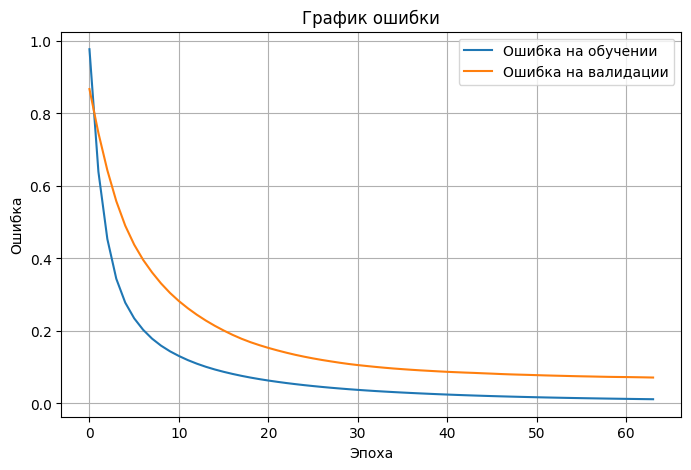

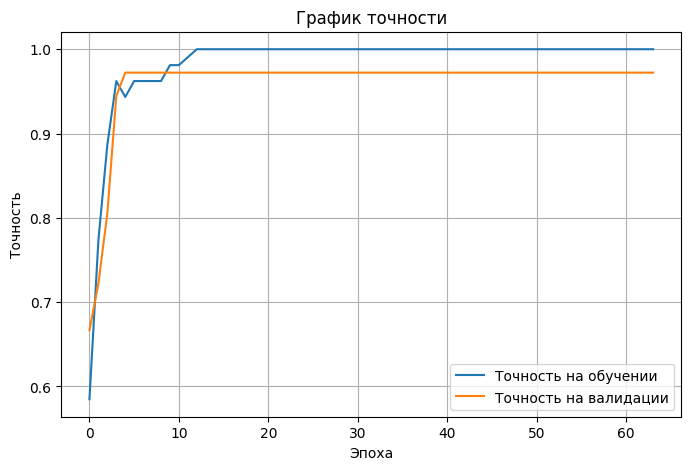

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,459 (13.51 KB)

 Trainable params: 3,267 (12.76 KB)

 Non-trainable params: 192 (768.00 B)

In [6]:
m1 = Wine_classific(epochs = 64, batch_size = 16, use_bn = True)
history, loss, accuracy = m1.train_model()
print(accuracy)
m1.plot_history(history)
m1.summary()